In [452]:
import pandas as pd
import matplotlib.pyplot as plt

In [453]:
# Load the data
file_path = 'data/NetflixViewingHistoryAlex.csv'
netflix_data = pd.read_csv(file_path)

# Extract the show title from the 'Title' column
netflix_data['Show_Title'] = netflix_data['Title'].apply(lambda x: x.split(':')[0])

# Convert the 'Date' column to datetime format
netflix_data['Date'] = pd.to_datetime(netflix_data['Date'], format='%d.%m.%y')
netflix_data['Year'] = netflix_data['Date'].dt.year

# Display the first few rows of the dataset to understand its structure
netflix_data.head()

,Title,Date,Show_Title,Year
0,Little Women,2024-07-23,Little Women,2024
1,3 Body Problem: Staffel 1: Der Weltenzerstörer,2024-07-19,3 Body Problem,2024
2,3 Body Problem: Staffel 1: Rotes Ufer,2024-07-19,3 Body Problem,2024
3,3 Body Problem: Staffel 1: Countdown,2024-07-18,3 Body Problem,2024
4,Bonn: Staffel 1: Episode 6,2024-07-11,Bonn,2024


In [454]:
# Calculate the total number of unique shows in the dataset
total_unique_shows = netflix_data['Show_Title'].nunique()
total_unique_shows

140

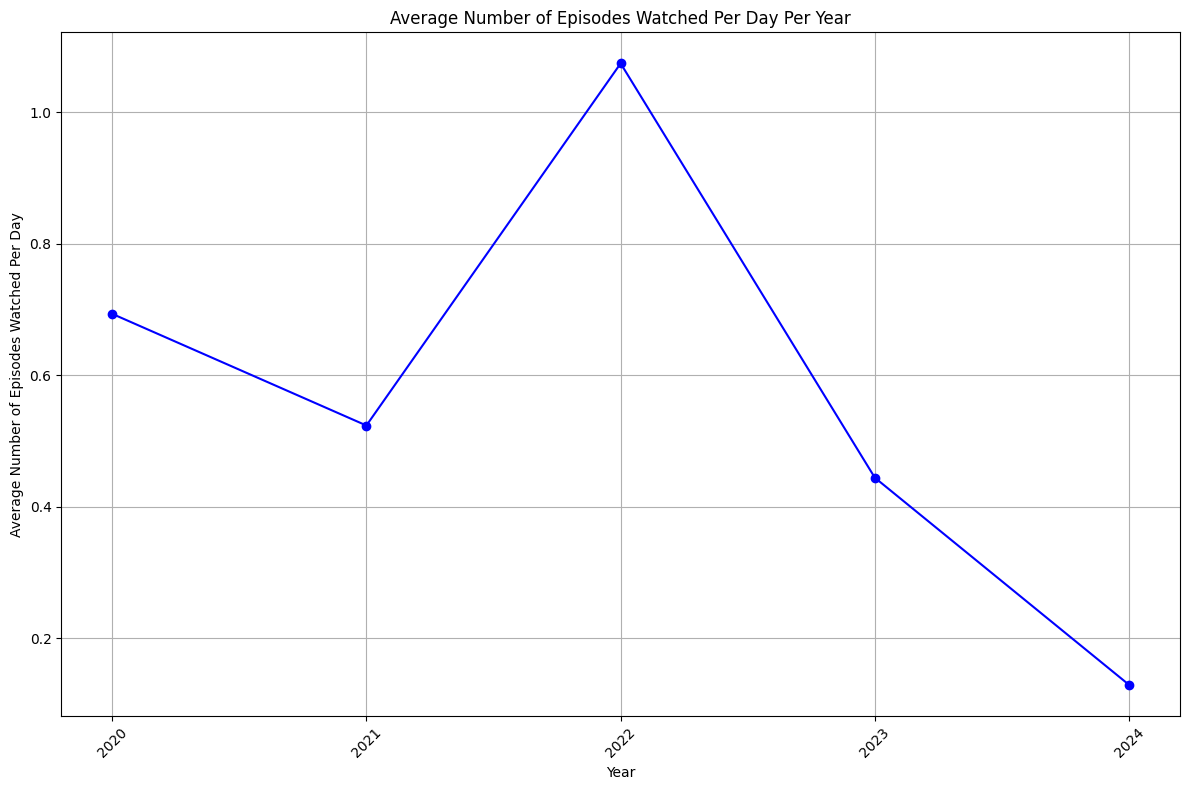

In [455]:
# Calculate the total number of episodes watched per year
total_episodes_per_year = netflix_data.groupby('Year').size()

# Calculate the number of days with any episodes watched per year
days_with_episodes_per_year = netflix_data.groupby('Year')['Date'].nunique()

# Calculate the average number of episodes watched per day per year
average_episodes_per_day_per_year = total_episodes_per_year / 365

# Plotting the average number of episodes watched per day for each year as a line plot
plt.figure(figsize=(12, 8))
plt.plot(average_episodes_per_day_per_year.index, average_episodes_per_day_per_year, marker='o', linestyle='-', color='b')
plt.title('Average Number of Episodes Watched Per Day Per Year')
plt.xlabel('Year')
plt.ylabel('Average Number of Episodes Watched Per Day')
plt.grid(True)
plt.xticks(average_episodes_per_day_per_year.index, rotation=45)
plt.tight_layout()

# Show plot
plt.show()


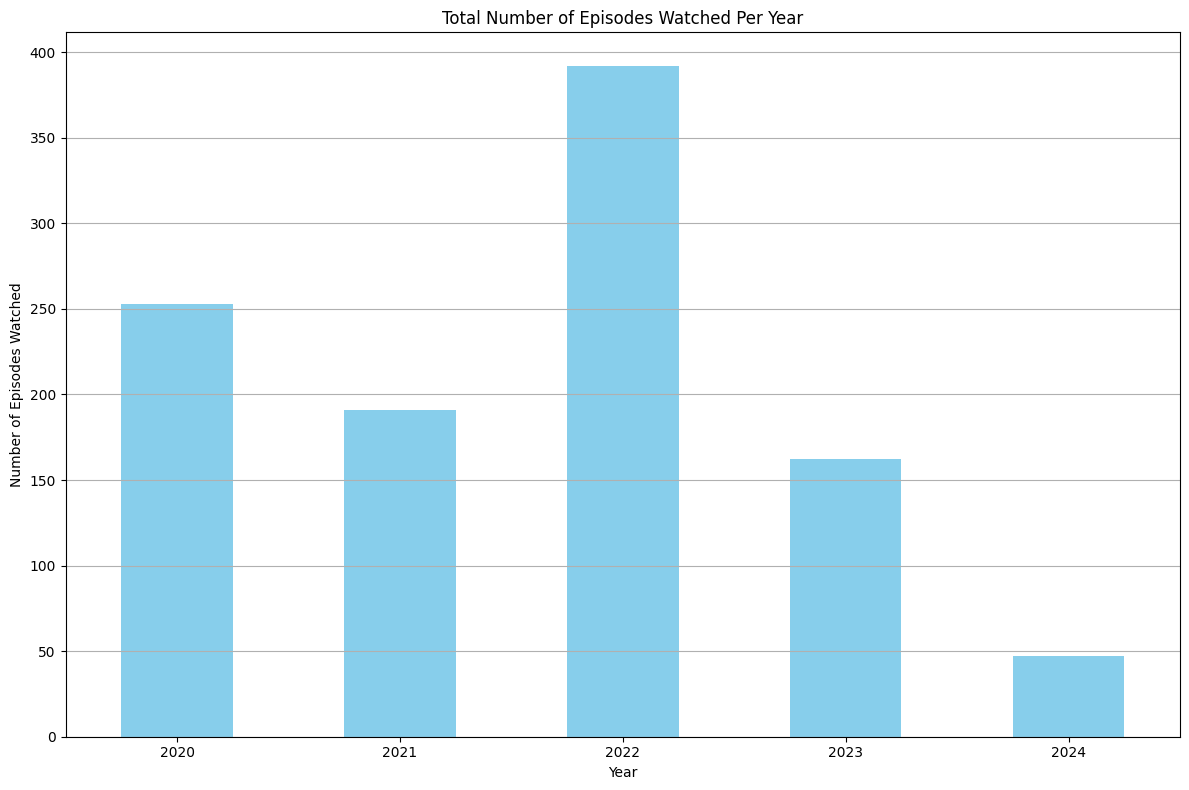

In [456]:
# Calculate the cumulative number of episodes watched per year
episodes_per_year = netflix_data.groupby('Year').size()

# Plotting the cumulative number of episodes watched per year as a bar chart
plt.figure(figsize=(12, 8))
episodes_per_year.plot(kind='bar', color='skyblue')
plt.title('Total Number of Episodes Watched Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Episodes Watched')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()

# Show plot
plt.show()


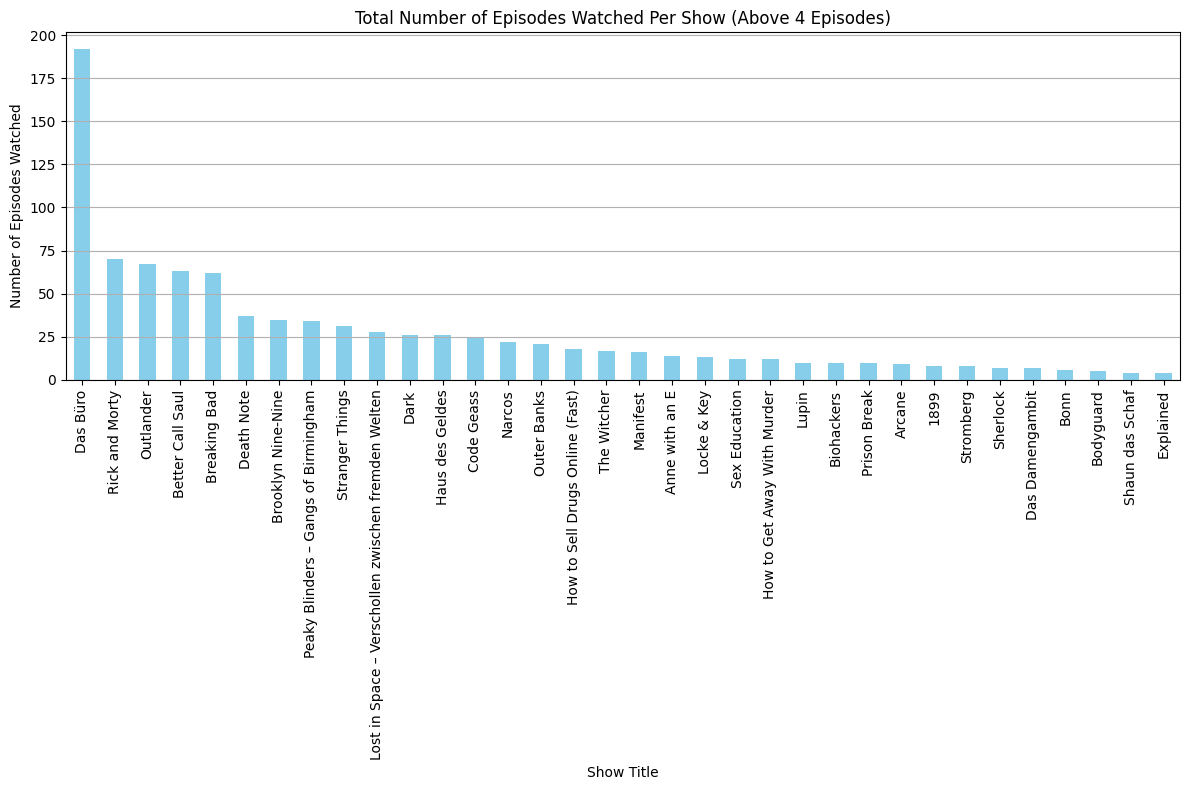

In [457]:
# Calculate the number of episodes watched per show
episodes_per_show = netflix_data['Show_Title'].value_counts()

# Filter out shows with less than 4 episodes watched
episodes_above_4 = episodes_per_show[episodes_per_show >= 4]

# Plotting the filtered number of episodes watched per show as a bar chart
plt.figure(figsize=(12, 8))
episodes_above_4.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Total Number of Episodes Watched Per Show (Above 4 Episodes)')
plt.xlabel('Show Title')
plt.ylabel('Number of Episodes Watched')
plt.grid(axis='y')
plt.xticks(rotation=90)
plt.tight_layout()

# Show plot
plt.show()


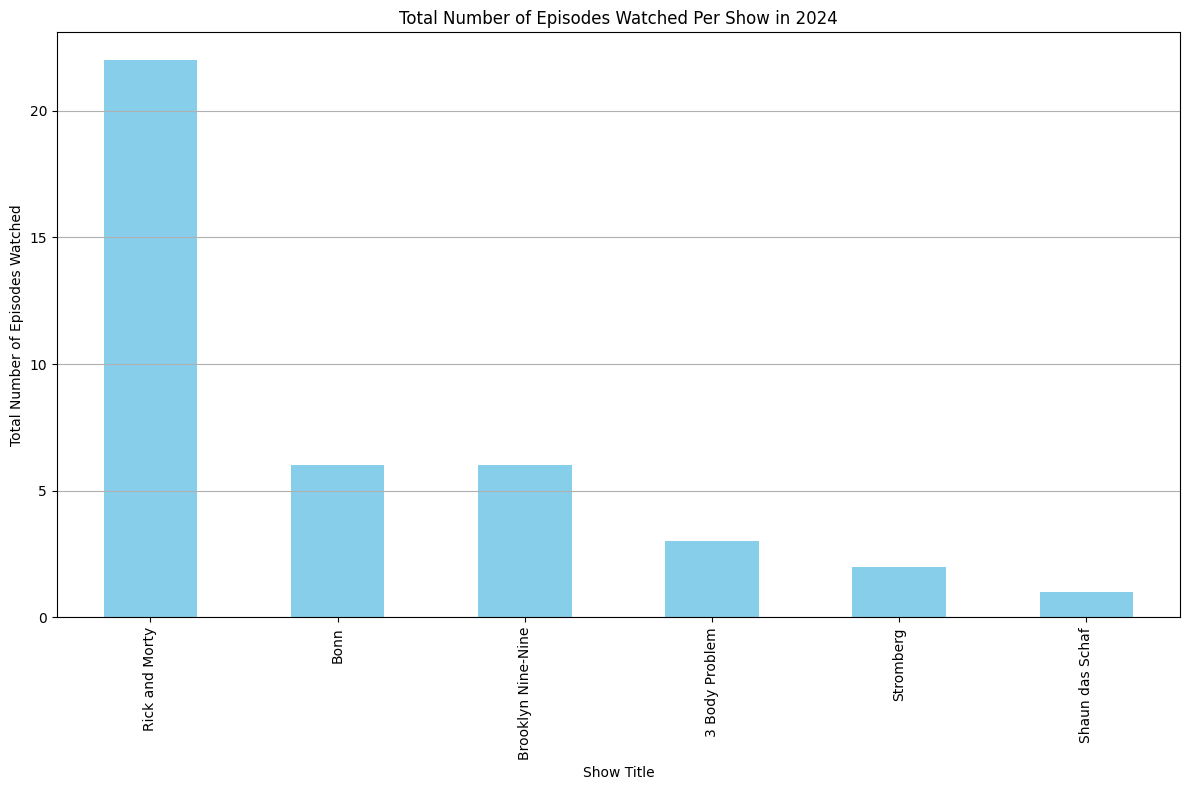

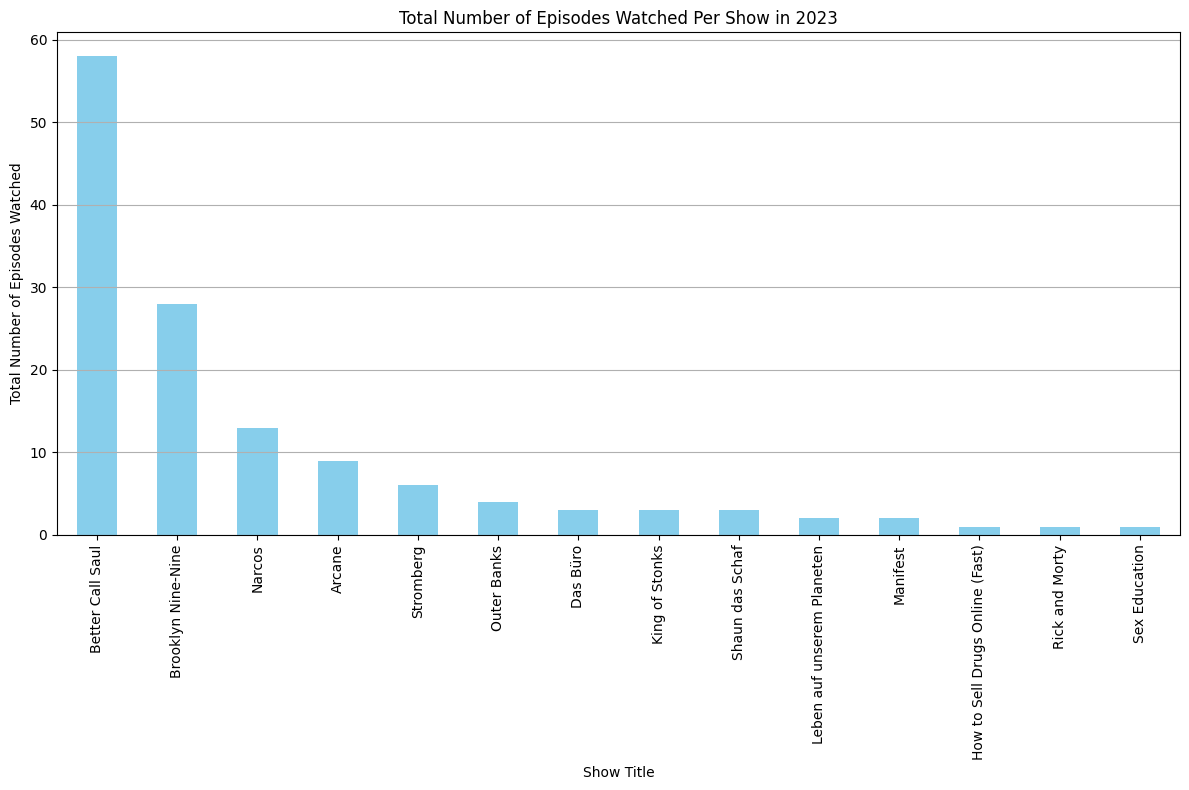

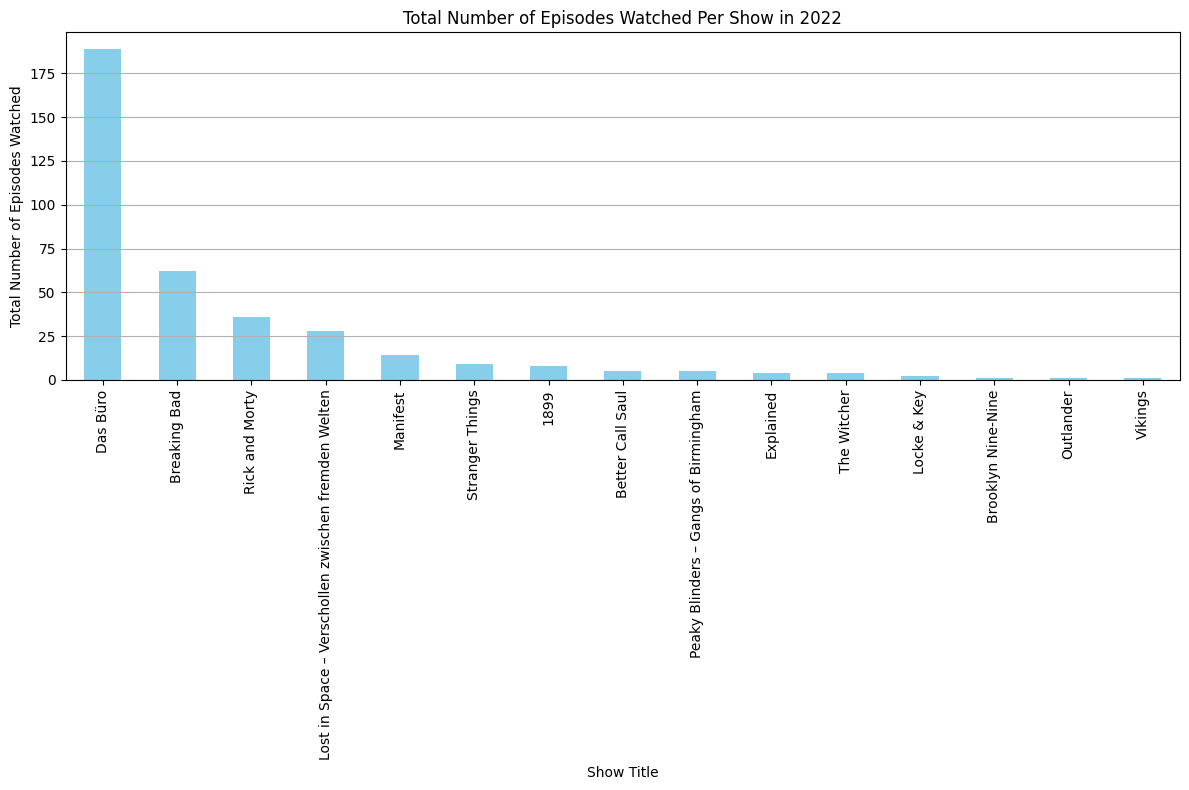

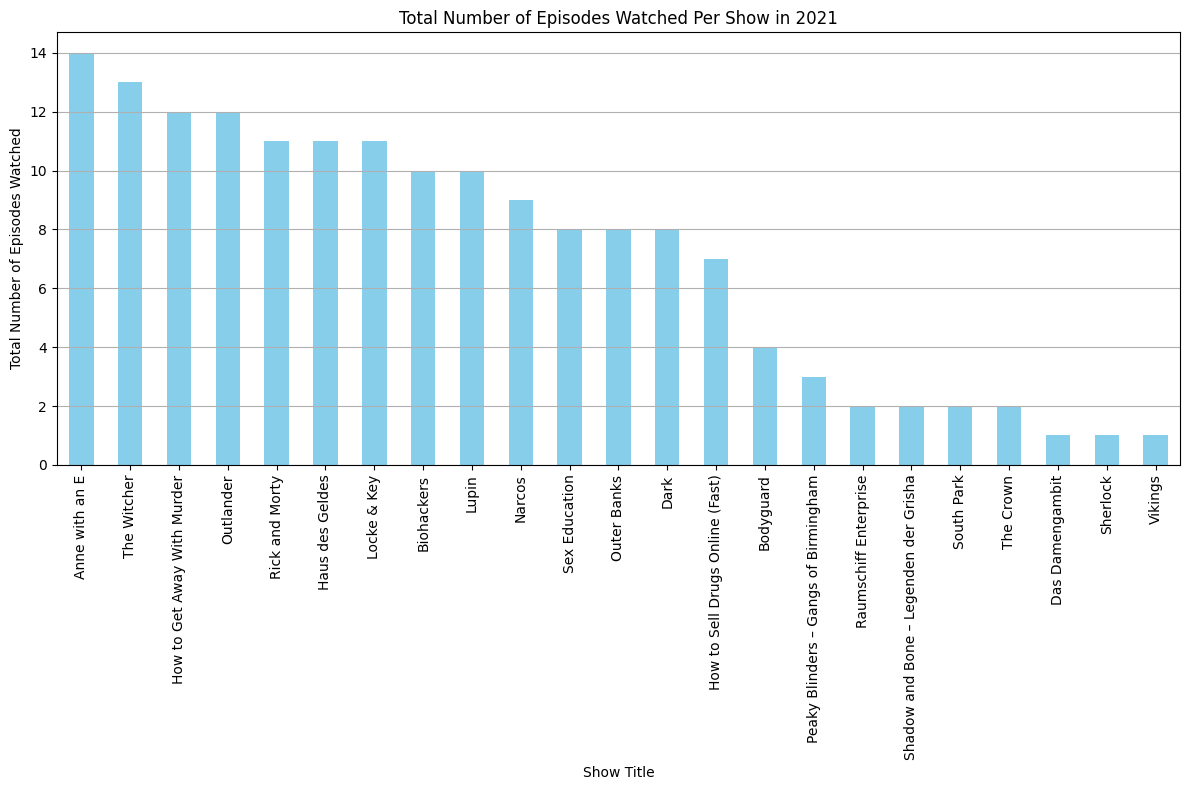

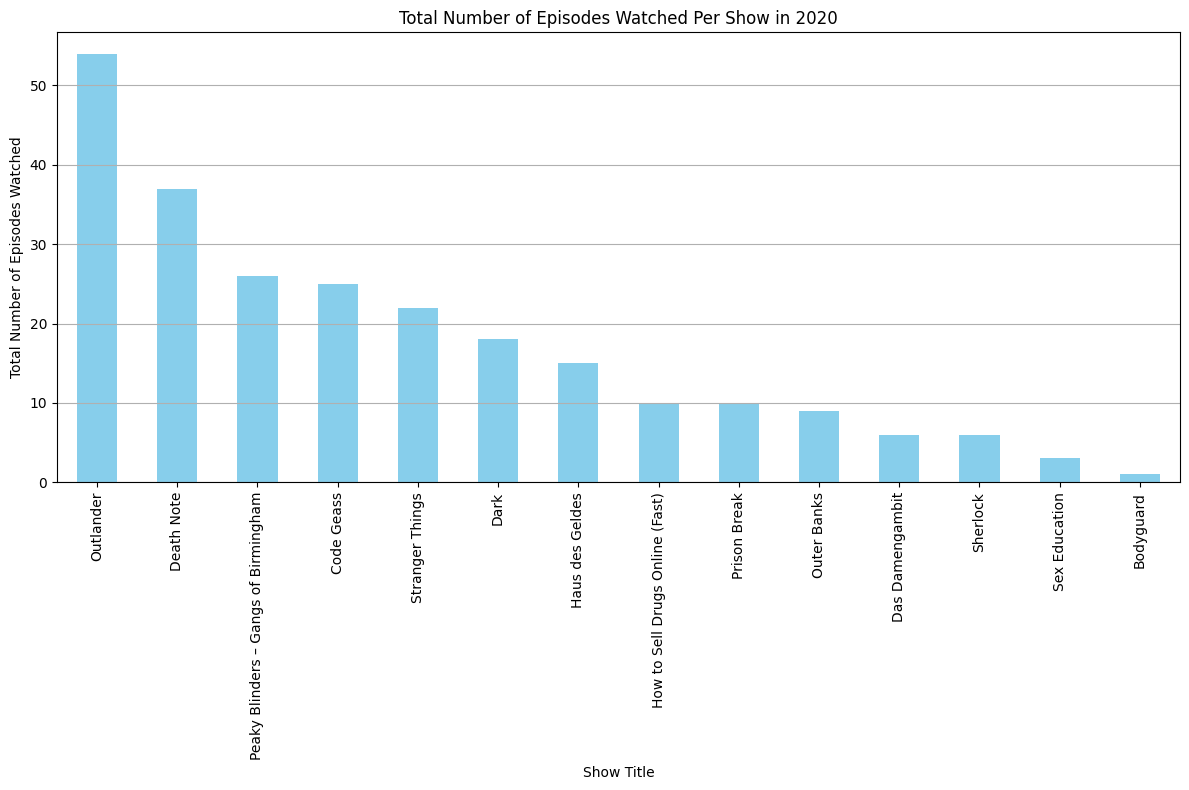

In [458]:
# Function to plot total hours watched per show for a given year
def plot_total_hours_per_show_by_year(year):
    data_year = netflix_data[netflix_data['Year'] == year]
    episodes_per_show_year = data_year.groupby('Show_Title')['Title'].count()
    episodes_per_show_year_above_1 = episodes_per_show_year[episodes_per_show > 1]
    
    plt.figure(figsize=(12, 8))
    episodes_per_show_year_above_1.sort_values(ascending=False).plot(kind='bar', color='skyblue')
    plt.title(f'Total Number of Episodes Watched Per Show in {year}')
    plt.xlabel('Show Title')
    plt.ylabel('Total Number of Episodes Watched')
    plt.grid(axis='y')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# List of other years in the dataset
years = netflix_data['Year'].unique()

# Plotting the charts for each other year
for year in years:
    plot_total_hours_per_show_by_year(year)


In [459]:
# List the shows watched in order of date
shows_watched_by_date = netflix_data[['Date', 'Show_Title']].sort_values(by='Date')
shows_watched_by_date.head()


,Date,Show_Title
1044,2020-02-11,Sex Education
1043,2020-02-13,Sex Education
1042,2020-02-13,Sex Education
1041,2020-02-24,Bodyguard
1040,2020-03-06,Stranger Things


In [460]:
# Aggregate multiple entries with the same show title to one row with the first date of the group
aggregated_shows_watched = shows_watched_by_date.groupby('Show_Title').first().reset_index()
aggregated_shows_watched.head()


,Show_Title,Date
0,10 Cloverfield Lane,2022-10-12
1,1899,2022-11-20
2,25 KM/H,2023-11-17
3,3 Body Problem,2024-07-18
4,365 Days,2020-07-20


In [461]:
# Sort the aggregated list of shows watched by date
aggregated_shows_watched_sorted = aggregated_shows_watched.sort_values(by='Date', ascending=False).reset_index(drop=True)
aggregated_shows_watched_sorted.head()


,Show_Title,Date
0,Little Women,2024-07-23
1,3 Body Problem,2024-07-18
2,Bonn,2024-07-04
3,The Night Agent,2024-07-04
4,Der Diktator,2024-07-03


In [462]:
# Add the episode count to the aggregated list of shows
episode_counts = netflix_data['Show_Title'].value_counts().reset_index()
episode_counts.columns = ['Show_Title', 'Episode_Count']

# Merge the episode count with the aggregated list
aggregated_shows_watched_with_counts = aggregated_shows_watched_sorted.merge(episode_counts, on='Show_Title', how='left')
aggregated_shows_watched_with_counts

,Show_Title,Date,Episode_Count
0,Little Women,2024-07-23,1
1,3 Body Problem,2024-07-18,3
2,Bonn,2024-07-04,6
3,The Night Agent,2024-07-04,1
4,Der Diktator,2024-07-03,1
...,...,...,...
135,Haus des Geldes,2020-03-27,26
136,Outlander,2020-03-20,67
137,Stranger Things,2020-03-06,31
138,Bodyguard,2020-02-24,5


### Attention only correct for Jan Lieders Data

In [463]:
# Define the average episode lengths for the top 25 shows
average_episode_lengths_25 = {
    "The Blacklist": 43,
    "Suits": 42,
    "Dexter": 55,
    "JoJo’s Bizarre Adventure": 24,
    "Rick and Morty": 22,
    "Better Call Saul": 47,
    "Breaking Bad": 47,
    "Manifest": 42,
    "Haikyu!!": 24,
    "The Last Kingdom": 58,
    "Designated Survivor": 42,
    "Death Note": 23,
    "Food Wars! Shokugeki no Soma": 24,
    "Stranger Things": 50,
    "Bleach": 24,
    "StartUp": 45,
    "The Witcher": 60,
    "Yellowstone": 42,
    "Haus des Geldes": 50,
    "The Sinner": 45,
    "Magic Kaito 1412": 24,
    "Akame Ga Kill": 23,
    "Guilty Crown": 24,
    "The Lincoln Lawyer": 50,
    "Ozark": 60
}

# Create a DataFrame for the top 25 shows with their average episode lengths
top_25_shows_df = pd.DataFrame(list(average_episode_lengths_25.items()), columns=['Show_Title', 'Average_Episode_Length_Minutes'])

# Merge this information back into the main dataset
netflix_data = netflix_data.merge(top_25_shows_df, on='Show_Title', how='left')

# For shows not in the top 25, fill in with the general average of 40 minutes
netflix_data['Average_Episode_Length_Minutes'] = netflix_data['Average_Episode_Length_Minutes'].fillna(40)

In [464]:
# Identify the top 25 shows by episode count
top_25_shows_by_episodes = netflix_data['Show_Title'].value_counts().head(25)

# Display the top 25 shows
top_25_shows_by_episodes

Show_Title
Das Büro                                               192
Rick and Morty                                          70
Outlander                                               67
Better Call Saul                                        63
Breaking Bad                                            62
Death Note                                              37
Brooklyn Nine-Nine                                      35
Peaky Blinders – Gangs of Birmingham                    34
Stranger Things                                         31
Lost in Space – Verschollen zwischen fremden Welten     28
Dark                                                    26
Haus des Geldes                                         26
Code Geass                                              25
Narcos                                                  22
Outer Banks                                             21
How to Sell Drugs Online (Fast)                         18
The Witcher                                  

<Figure size 1200x800 with 0 Axes>

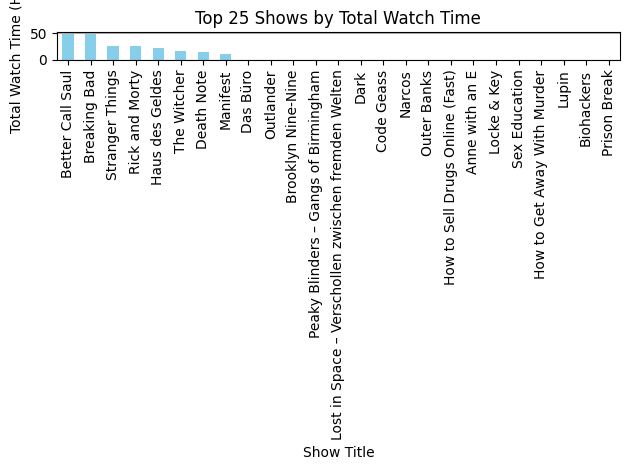

In [465]:
# Calculate the total watch time for the top 25 shows by episode count
top_25_shows_by_episodes_df = top_25_shows_by_episodes.reset_index()
top_25_shows_by_episodes_df.columns = ['Show_Title', 'Episode_Count']

# Merge the average episode lengths into the top 25 shows dataframe
top_25_shows_with_lengths = top_25_shows_by_episodes_df.merge(top_25_shows_df, on='Show_Title', how='left')

# Calculate the total watch time in minutes
top_25_shows_with_lengths['Total_Watch_Time_Minutes'] = top_25_shows_with_lengths['Episode_Count'] * top_25_shows_with_lengths['Average_Episode_Length_Minutes']

# Convert total watch time to hours
top_25_shows_with_lengths['Total_Watch_Time_Hours'] = top_25_shows_with_lengths['Total_Watch_Time_Minutes'] / 60

# Sort the top 25 shows by total watch time in descending order
top_25_shows_sorted_by_watch_time = top_25_shows_with_lengths.sort_values(by='Total_Watch_Time_Hours', ascending=False)

# Plotting the total watch time for the top 25 shows as a bar chart
plt.figure(figsize=(12, 8))
top_25_shows_sorted_by_watch_time.plot(kind='bar', x='Show_Title', y='Total_Watch_Time_Hours', color='skyblue', legend=False)
plt.title('Top 25 Shows by Total Watch Time')
plt.xlabel('Show Title')
plt.ylabel('Total Watch Time (Hours)')
plt.grid(axis='y')
plt.xticks(rotation=90)
plt.tight_layout()

# Show plot
plt.show()


In [466]:
# Group by year and calculate the total minutes watched per day for each year
total_minutes_per_day_per_year = netflix_data.groupby(['Year', 'Date'])['Average_Episode_Length_Minutes'].sum()

# Convert minutes to hours and calculate the average hours per day for each year
total_hours_per_day_per_year = total_minutes_per_day_per_year / 60
average_hours_per_day_per_year = total_hours_per_day_per_year.groupby('Year').mean()

# Convert the result to a DataFrame for better visualization
average_hours_per_day_per_year_df = average_hours_per_day_per_year.reset_index()
average_hours_per_day_per_year_df.columns = ['Year', 'Average_Hours_Per_Day']
average_hours_per_day_per_year_df


,Year,Average_Hours_Per_Day
0,2020,1.336856
1,2021,1.152212
2,2022,1.453611
3,2023,1.080503
4,2024,0.883333


### Correct for everyone again (estimation)

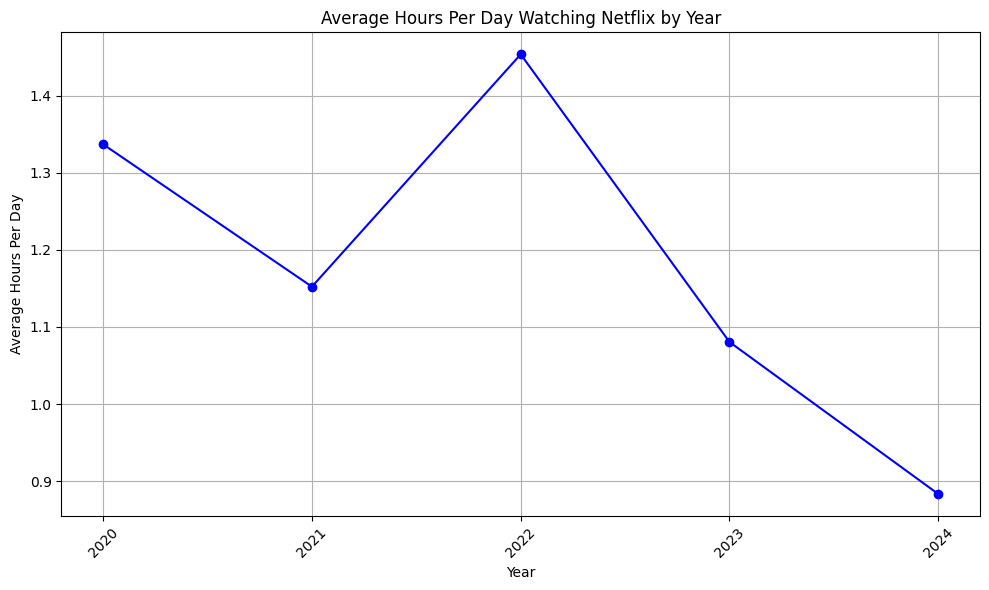

In [467]:
# Plotting the average hours per day for each year
plt.figure(figsize=(10, 6))
plt.plot(average_hours_per_day_per_year_df['Year'], average_hours_per_day_per_year_df['Average_Hours_Per_Day'], marker='o', linestyle='-', color='b')
plt.title('Average Hours Per Day Watching Netflix by Year')
plt.xlabel('Year')
plt.ylabel('Average Hours Per Day')
plt.grid(True)
plt.xticks(average_hours_per_day_per_year_df['Year'], rotation=45)
plt.tight_layout()

# Show plot
plt.show()

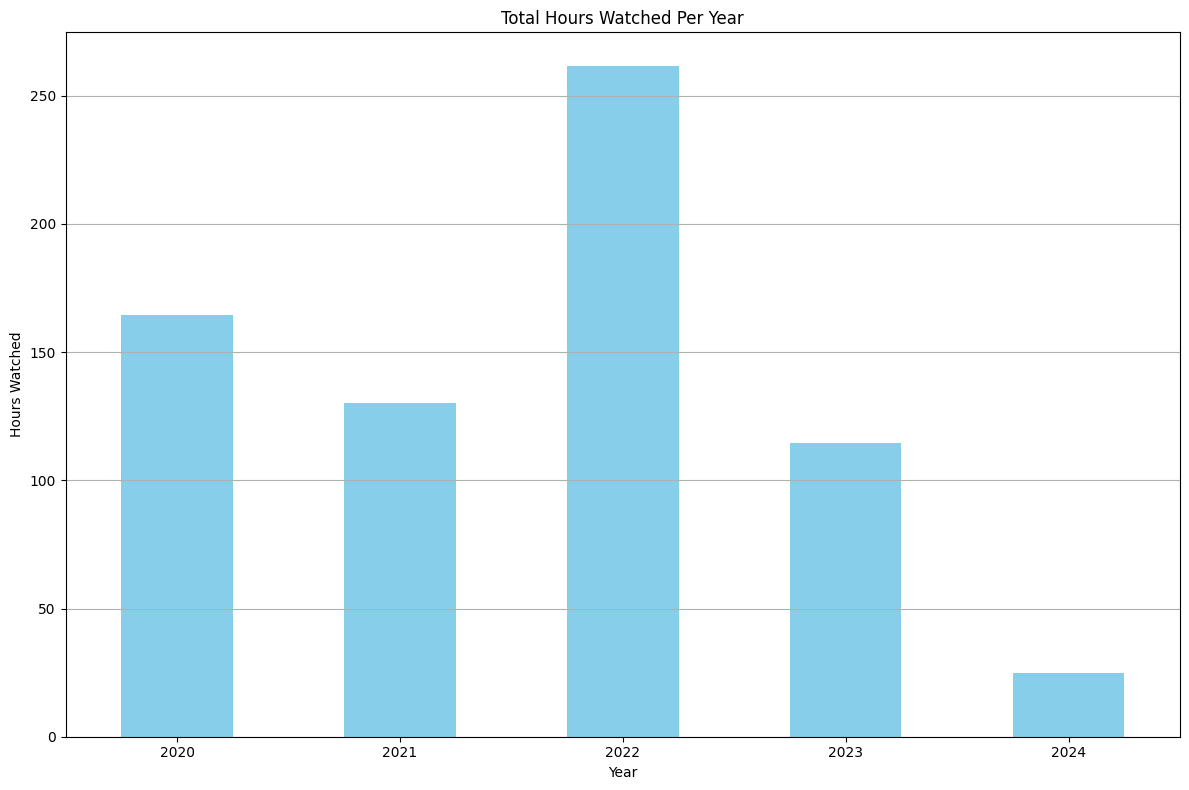

In [468]:
# Calculate the cumulative number of episodes watched per year
total_minutes_per_year = netflix_data.groupby(['Year'])['Average_Episode_Length_Minutes'].sum()
total_hours_per_year = total_minutes_per_year / 60

# Plotting the cumulative number of episodes watched per year as a bar chart
plt.figure(figsize=(12, 8))
total_hours_per_year.plot(kind='bar', color='skyblue')
plt.title('Total Hours Watched Per Year')
plt.xlabel('Year')
plt.ylabel('Hours Watched')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()

# Show plot
plt.show()
